# Day 6/60 — Content Delivery Network (CDN)

## System Design Series

**Topic:** A CDN is a geographically distributed network of edge servers that caches static content close to users — slashing latency by 80-95% for global audiences.

**What we cover:**
- Global CDN architecture: origin + PoP nodes + geographic routing
- 6-step CDN workflow: first request (miss) vs repeat request (hit)
- Latency impact by region and CDN warm-up behaviour
- TTL lifecycle, cache invalidation strategies
- CDN considerations: cost, fallback, content classification
- Pull CDN vs Push CDN + provider landscape
- Architecture evolution and Day 6 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE    = '#4C72B0'
C_GREEN   = '#27AE60'
C_ORANGE  = '#DD8452'
C_RED     = '#C44E52'
C_TEAL    = '#2E86AB'
C_GRAY    = '#F8F9FA'
C_ORIGIN  = '#8E44AD'   # purple  — origin server / S3
C_CDN     = '#E67E22'   # amber   — CDN PoP node
C_USER    = '#2E86AB'   # teal    — end user
C_HIT     = '#27AE60'   # green   — cache hit
C_MISS    = '#E74C3C'   # red     — cache miss / origin fetch
C_EDGE    = '#F39C12'   # gold    — CDN edge

print("Libraries loaded. Day 6 ready.")


Libraries loaded. Day 6 ready.


### What this does

Loads Matplotlib and NumPy, and defines the Day 6 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_ORIGIN` | Purple | Origin server / S3 storage |
| `C_CDN` | Amber | CDN PoP (Point of Presence) |
| `C_USER` | Teal | End user / browser |
| `C_HIT` | Green | Cache hit — served from edge |
| `C_MISS` | Red | Cache miss — origin fetch required |
| `C_EDGE` | Gold | CDN edge network |

The green/red hit-miss colour language is consistent with Day 5 (Cache).

## 2. Global CDN Architecture

A CDN has two types of nodes:

- **Origin server:** Your actual web server or cloud storage (S3/GCS/Azure Blob). Holds the canonical, always-up-to-date copy. Located in one region.
- **PoP (Point of Presence):** Edge cache servers distributed worldwide. Cloudflare has 300+, Akamai has 4000+. Each PoP serves users in its geographic vicinity.

> **The rule:** Users talk to their nearest PoP. The PoP talks to the origin only on a miss.

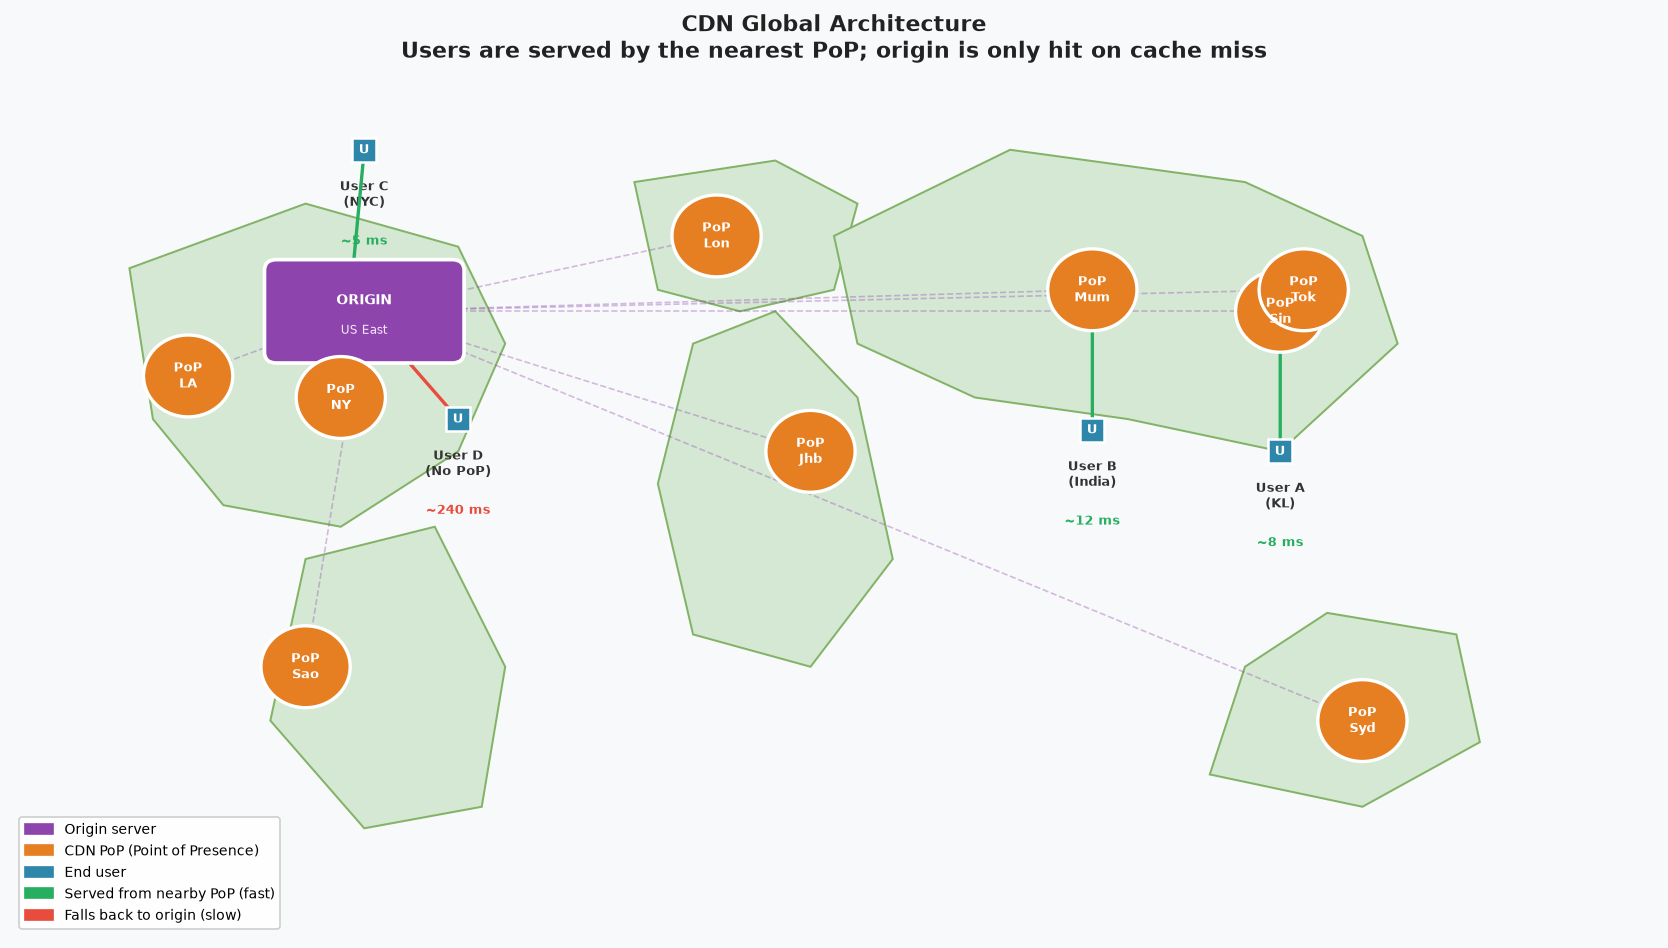

Global architecture done.


In [2]:
# CDN global architecture: world map with origin + PoP nodes + user latency

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14); ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#EAF4FB')
fig.patch.set_facecolor(C_GRAY)

# ── Stylised world map outline (simplified continent blobs) ───────────────────
continent_patches = [
    # North America
    plt.Polygon([[1.2,4.8],[1.0,6.2],[2.5,6.8],[3.8,6.4],[4.2,5.5],
                 [3.8,4.5],[2.8,3.8],[1.8,4.0]], closed=True,
                facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
    # South America
    plt.Polygon([[2.5,3.5],[2.2,2.0],[3.0,1.0],[4.0,1.2],[4.2,2.5],[3.6,3.8]],
                closed=True, facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
    # Europe
    plt.Polygon([[5.5,6.0],[5.3,7.0],[6.5,7.2],[7.2,6.8],[7.0,6.0],[6.2,5.8]],
                closed=True, facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
    # Africa
    plt.Polygon([[5.8,5.5],[5.5,4.2],[5.8,2.8],[6.8,2.5],[7.5,3.5],
                 [7.2,5.0],[6.5,5.8]], closed=True,
                facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
    # Asia
    plt.Polygon([[7.2,5.5],[7.0,6.5],[8.5,7.3],[10.5,7.0],[11.5,6.5],
                 [11.8,5.5],[10.8,4.5],[9.5,4.8],[8.2,5.0]], closed=True,
                facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
    # Australia
    plt.Polygon([[10.5,2.5],[10.2,1.5],[11.5,1.2],[12.5,1.8],[12.3,2.8],[11.2,3.0]],
                closed=True, facecolor='#D5E8D4', edgecolor='#82b366', lw=1.2),
]
for p in continent_patches:
    ax.add_patch(p)

def pop_node(ax, x, y, label, color=C_CDN, r=0.38, fs=8):
    circle = plt.Circle((x, y), r, facecolor=color, edgecolor='white', lw=2.0, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white', zorder=6)

def user_icon(ax, x, y, label, latency, lat_color):
    ax.plot(x, y, 's', color=C_USER, ms=14, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.text(x, y, 'U', ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=6)
    ax.text(x, y - 0.52, label, ha='center', fontsize=7.5,
            color='#333', fontweight='bold')
    ax.text(x, y - 0.88, latency, ha='center', fontsize=7.5,
            color=lat_color, fontweight='bold')

# ── Origin server (US East) ───────────────────────────────────────────────────
ox, oy = 3.0, 5.8
r_orig = FancyBboxPatch((ox - 0.75, oy - 0.38), 1.5, 0.76,
                        boxstyle='round,pad=0.1',
                        facecolor=C_ORIGIN, edgecolor='white', lw=2.2, zorder=5)
ax.add_patch(r_orig)
ax.text(ox, oy + 0.1,  'ORIGIN', ha='center', va='center',
        fontsize=8.5, fontweight='bold', color='white', zorder=6)
ax.text(ox, oy - 0.18, 'US East', ha='center', va='center',
        fontsize=7, color='white', alpha=0.9, zorder=6)

# ── CDN PoP nodes ─────────────────────────────────────────────────────────────
pops = [
    (2.8, 5.0,  'PoP\nNY'),
    (1.5, 5.2,  'PoP\nLA'),
    (6.0, 6.5,  'PoP\nLon'),
    (6.8, 4.5,  'PoP\nJhb'),
    (9.2, 6.0,  'PoP\nMum'),
    (10.8,5.8,  'PoP\nSin'),
    (11.5,2.0,  'PoP\nSyd'),
    (11.0,6.0,  'PoP\nTok'),
    (2.5, 2.5,  'PoP\nSao'),
]
for px, py, lbl in pops:
    pop_node(ax, px, py, lbl)

# ── Origin -> PoP replication lines (faint) ───────────────────────────────────
for px, py, _ in pops:
    ax.plot([ox, px], [oy, py], color=C_ORIGIN, lw=1.0, alpha=0.35,
            linestyle='--', zorder=3)

# ── Users ─────────────────────────────────────────────────────────────────────
users = [
    (10.8, 4.5, 'User A\n(KL)', '~8 ms', C_HIT),   # near Singapore PoP
    (9.2,  4.7, 'User B\n(India)', '~12 ms', C_HIT),
    (3.0,  7.3, 'User C\n(NYC)', '~5 ms', C_HIT),
    (3.8,  4.8, 'User D\n(No PoP)', '~240 ms', C_MISS),
]
for ux, uy, lbl, lat, lc in users:
    user_icon(ax, ux, uy, lbl, lat, lc)

# User -> nearest PoP arrows (solid, coloured)
pop_map = {
    'User A\n(KL)':     (10.8, 5.8),
    'User B\n(India)':  (9.2,  6.0),
    'User C\n(NYC)':    (2.8,  5.0),
    'User D\n(No PoP)': (ox,   oy),
}
arrow_colors = [C_HIT, C_HIT, C_HIT, C_MISS]
for (ux, uy, lbl, lat, lc), ac in zip(users, arrow_colors):
    tx, ty = pop_map[lbl]
    ax.annotate('', xy=(tx, ty), xytext=(ux, uy),
                arrowprops=dict(arrowstyle='->', color=ac, lw=2.0, zorder=4))

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_ORIGIN, label='Origin server'),
    mpatches.Patch(color=C_CDN,    label='CDN PoP (Point of Presence)'),
    mpatches.Patch(color=C_USER,   label='End user'),
    mpatches.Patch(color=C_HIT,    label='Served from nearby PoP (fast)'),
    mpatches.Patch(color=C_MISS,   label='Falls back to origin (slow)'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCC')

ax.set_title('CDN Global Architecture\nUsers are served by the nearest PoP; origin is only hit on cache miss',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_global.png', dpi=130, bbox_inches='tight')
plt.show()
print("Global architecture done.")


### What this shows

The stylised world map shows the origin (purple, US East) and 9 CDN PoP nodes (amber circles) spanning North America, South America, Europe, Africa, Asia, and Australia.

**Green arrows:** Users A, B, and C are each routed to their nearest PoP with low latency (5–12 ms).  
**Red arrow:** User D is in a region with no nearby PoP — they fall back to the origin directly (240 ms), illustrating the gap in coverage.

**Dashed lines:** Background replication from origin to all PoPs (for push CDNs) or lazy fetch paths (for pull CDNs). The geographic spread is the CDN's core value proposition — physics limits the speed of light, and the only way to beat it is to put data closer to the user.

## 3. CDN Workflow: Steps 1–6

The CDN workflow described in the original Day 6 content maps to exactly two scenarios:

**Steps 1–4 (User A, first request — cache MISS):**
1. User A requests `image.png` using the CDN URL (e.g. `cdn.example.com/image.png`)
2. CDN PoP doesn't have it → fetches from origin
3. Origin returns `image.png` with `Cache-Control: max-age=86400` TTL header
4. CDN caches the image and serves it to User A

**Steps 5–6 (User B, same image — cache HIT):**
5. User B requests the same `image.png`
6. CDN serves it directly from edge cache — origin is never contacted

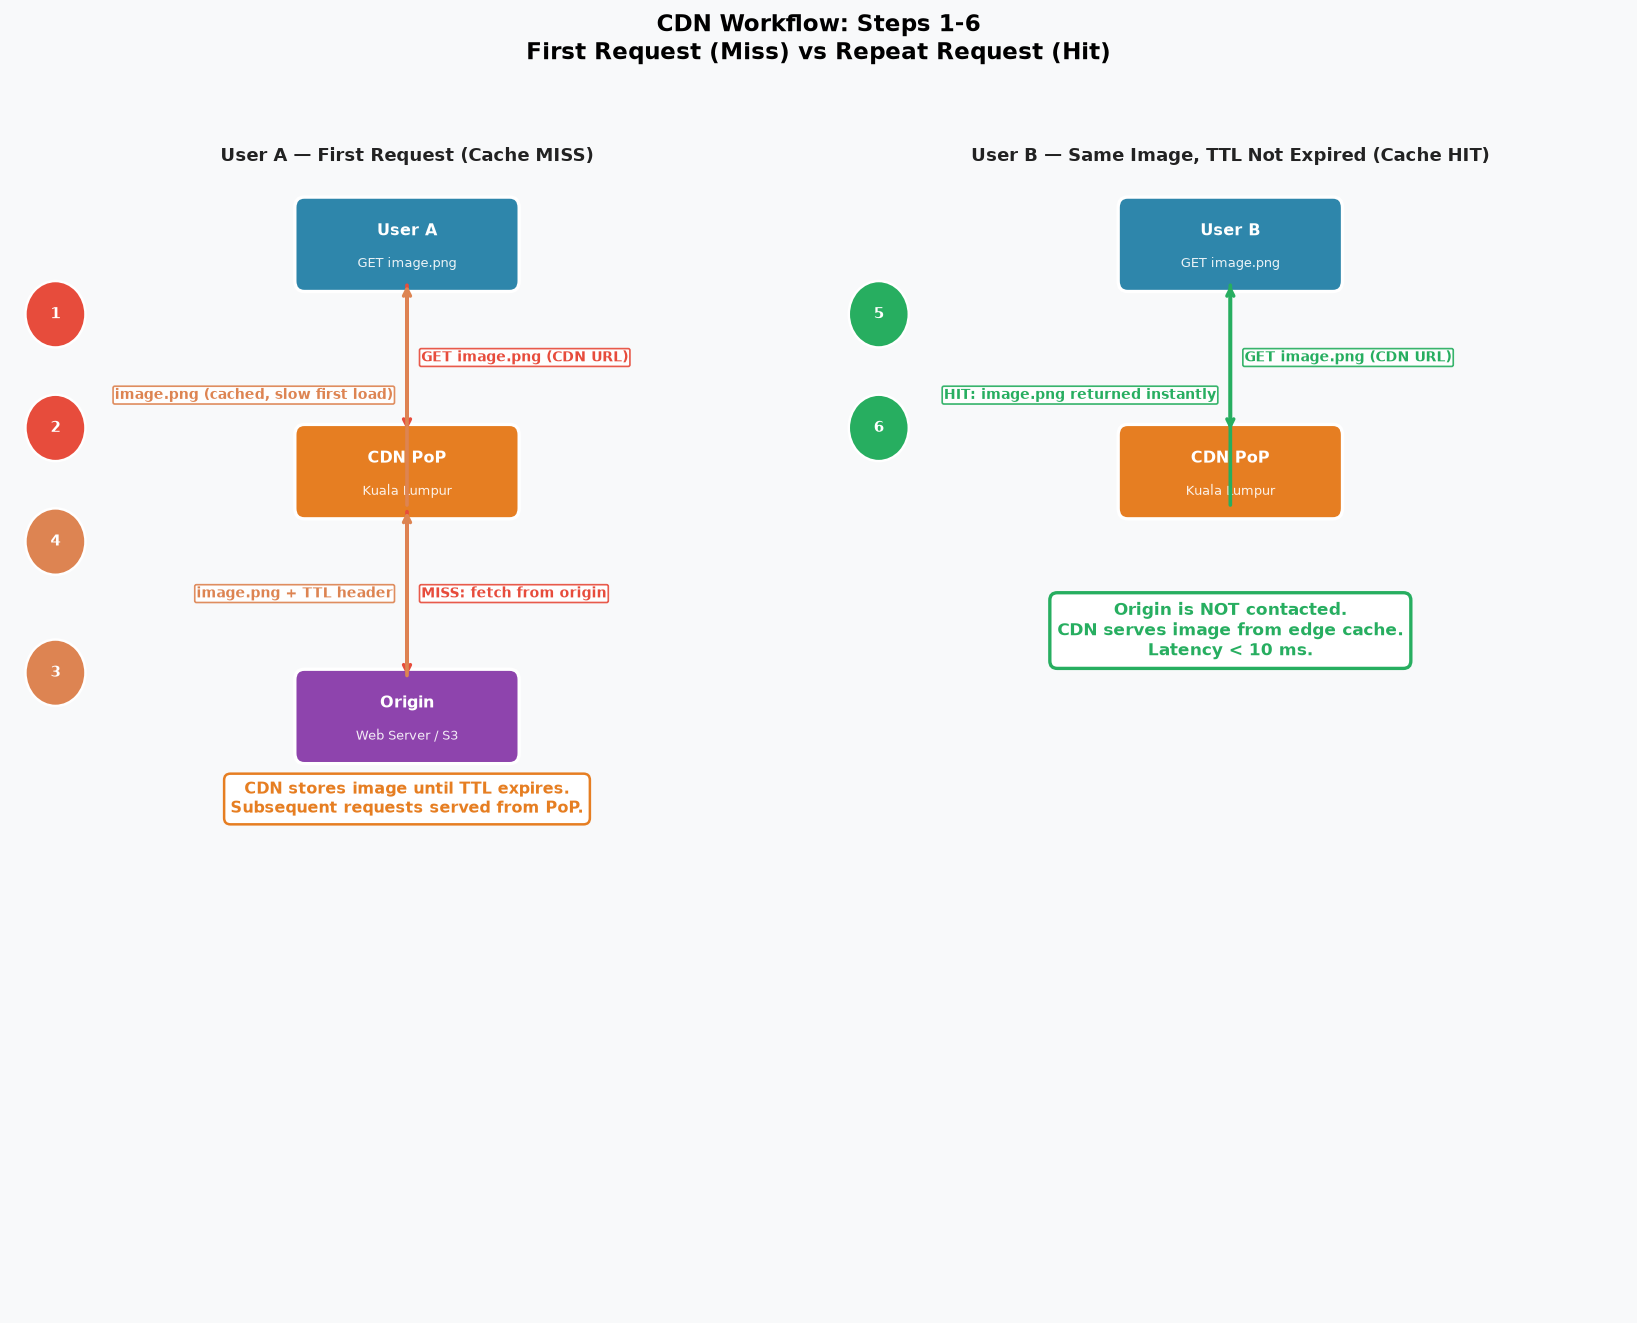

In [3]:
# CDN workflow: 6 numbered steps, User A miss then User B hit
# Two clean vertical columns: left = User A (miss), right = User B (hit)

fig, axes = plt.subplots(1, 2, figsize=(14, 11))
fig.patch.set_facecolor(C_GRAY)

def draw_workflow(ax, title, steps, actors, show_origin_fetch):
    ax.set_xlim(0, 10); ax.set_ylim(0, 13)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#222')

    def node(x, y, label, color, sub=''):
        r = FancyBboxPatch((x - 1.3, y - 0.42), 2.6, 0.84,
                           boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor='white', lw=2.0)
        ax.add_patch(r)
        ax.text(x, y + (0.15 if sub else 0), label,
                ha='center', va='center', fontsize=9.5,
                fontweight='bold', color='white')
        if sub:
            ax.text(x, y - 0.22, sub, ha='center', va='center',
                    fontsize=7.5, color='white', alpha=0.9)

    def arr(x1, y1, x2, y2, label, color, lw=2.2, side='right'):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw))
        mx, my = (x1 + x2)/2, (y1 + y2)/2
        ha = 'left' if side == 'right' else 'right'
        dx = 0.18 if side == 'right' else -0.18
        ax.text(mx + dx, my, label, ha=ha, va='center',
                fontsize=8.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=color, lw=1.0, alpha=0.92))

    # Static nodes
    node(5, 12.2, actors[0][0], actors[0][1], actors[0][2])   # user
    node(5,  9.6, actors[1][0], actors[1][1], actors[1][2])   # CDN PoP
    if show_origin_fetch:
        node(5,  6.8, actors[2][0], actors[2][1], actors[2][2])  # origin

    # Lifelines
    for ly in ([12.2, 9.6, 6.8] if show_origin_fetch else [12.2, 9.6]):
        ax.axvline(5, ymin=(ly - 0.5) / 13, ymax=(ly + 0.5) / 13,
                   color='#DDD', lw=0, linestyle=':')  # invisible — nodes are the anchors

    # Numbered step bubbles + arrows
    for (num, y, x1, y1, x2, y2, label, color, side) in steps:
        # Step number badge
        circle = plt.Circle((0.55, y), 0.38, facecolor=color,
                             edgecolor='white', lw=1.5, zorder=5)
        ax.add_patch(circle)
        ax.text(0.55, y, str(num), ha='center', va='center',
                fontsize=9, fontweight='bold', color='white', zorder=6)
        arr(x1, y1, x2, y2, label, color, side=side)

# ── User A flow: CDN miss -> fetch from origin ────────────────────────────────
user_a_actors = [
    ('User A',   C_USER,   'GET image.png'),
    ('CDN PoP',  C_CDN,    'Kuala Lumpur'),
    ('Origin',   C_ORIGIN, 'Web Server / S3'),
]
user_a_steps = [
    # (step_num, badge_y, arr_x1, y1, arr_x2, y2, label, color, side)
    (1, 11.4, 5, 11.77, 5, 10.04, 'GET image.png (CDN URL)', C_MISS,   'right'),
    (2, 10.1, 5, 9.18,  5,  7.23, 'MISS: fetch from origin', C_MISS,   'right'),
    (3,  7.3, 5, 7.23,  5,  9.18, 'image.png + TTL header',  C_ORANGE, 'left'),
    (4,  8.8, 5, 9.18,  5, 11.77, 'image.png (cached, slow first load)', C_ORANGE, 'left'),
]
draw_workflow(axes[0],
              'User A — First Request (Cache MISS)',
              user_a_steps, user_a_actors, show_origin_fetch=True)

# Add TTL annotation
axes[0].text(5, 5.7,
    'CDN stores image until TTL expires.\n'
    'Subsequent requests served from PoP.',
    ha='center', fontsize=9.5, color=C_CDN, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=C_CDN, lw=1.5))

# ── User B flow: CDN hit ───────────────────────────────────────────────────────
user_b_actors = [
    ('User B',   C_USER,   'GET image.png'),
    ('CDN PoP',  C_CDN,    'Kuala Lumpur'),
    ('',         '#EAF4FB', ''),   # placeholder — origin not shown
]
user_b_steps = [
    (5, 11.4, 5, 11.77, 5, 10.04, 'GET image.png (CDN URL)', C_HIT,  'right'),
    (6, 10.1, 5, 9.18,  5, 11.77, 'HIT: image.png returned instantly', C_HIT, 'left'),
]
draw_workflow(axes[1],
              'User B — Same Image, TTL Not Expired (Cache HIT)',
              user_b_steps, user_b_actors, show_origin_fetch=False)

axes[1].text(5, 7.5,
    'Origin is NOT contacted.\nCDN serves image from edge cache.\nLatency < 10 ms.',
    ha='center', fontsize=10, color=C_HIT, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
              edgecolor=C_HIT, lw=2.0))

plt.suptitle('CDN Workflow: Steps 1-6\nFirst Request (Miss) vs Repeat Request (Hit)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig('/tmp/sd_day6_workflow.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

Each panel is a clean vertical flow with numbered step badges on the left margin — no crossing arrows, one actor column centred.

**Left — User A (MISS):** Steps 1-4. Red arrows show the miss path down to the origin. Orange arrows show the return path as the CDN stores and serves the image. The slowest part is step 2 (CDN → origin); this only happens once per CDN node per TTL period.

**Right — User B (HIT):** Steps 5-6. Just two arrows — request goes to CDN, response comes straight back. Origin is completely absent from this diagram. This is the common case for any popular asset. Latency < 10 ms.

## 4. Latency Impact & CDN Warm-Up

The latency improvement is most dramatic for users who are geographically far from the origin:

| Region | No CDN | With CDN | Improvement |
|---|---|---|---|
| New York (origin city) | 10 ms | 8 ms | ~20% |
| London | 90 ms | 15 ms | **83%** |
| Mumbai | 160 ms | 20 ms | **88%** |
| Singapore | 180 ms | 18 ms | **90%** |
| Sydney | 210 ms | 22 ms | **90%** |

CDN provides almost no benefit for users co-located with the origin. The further the user, the bigger the win — making CDN essential for global products.

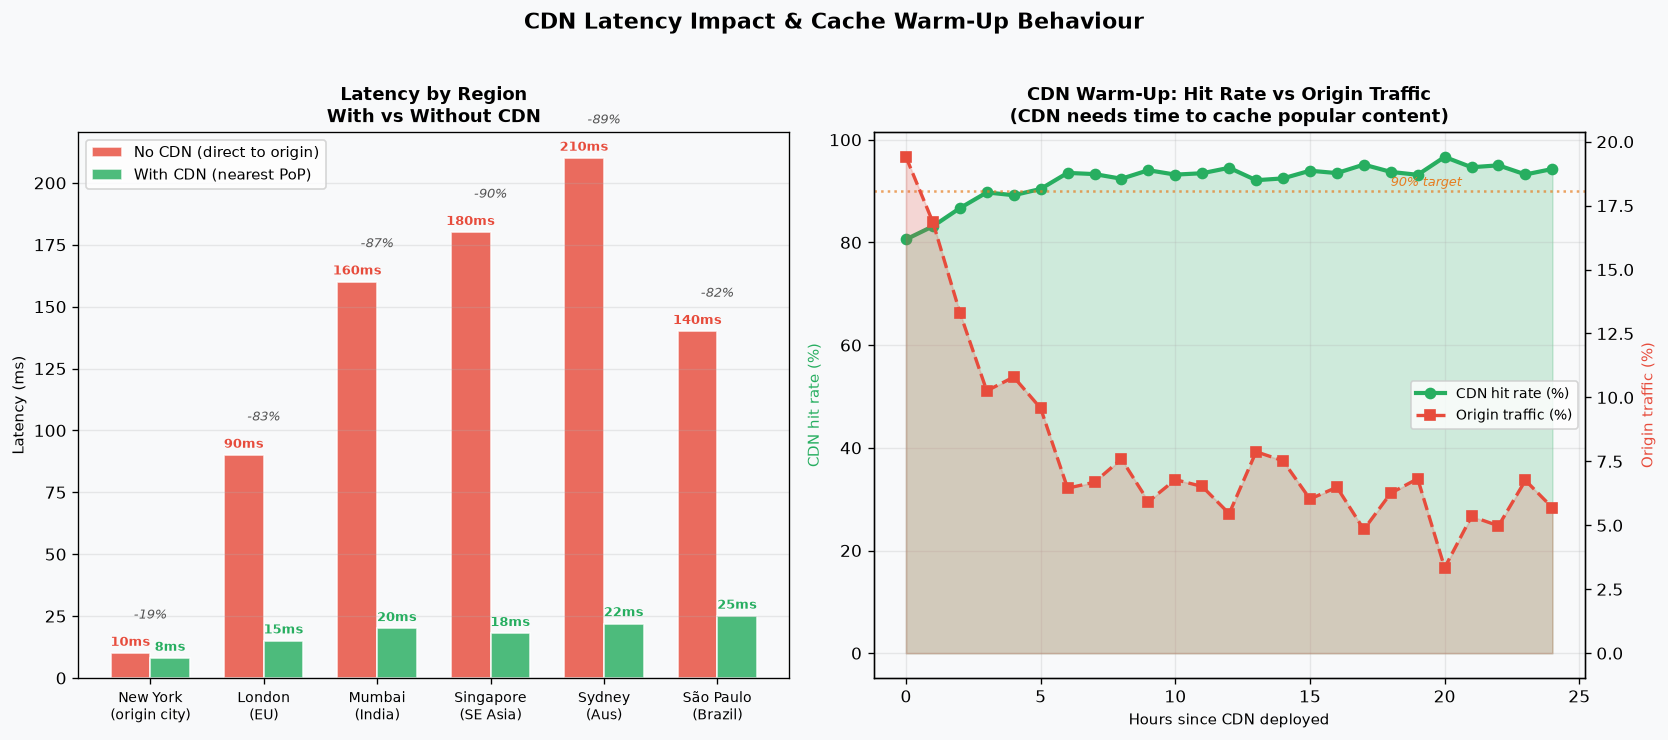

In [4]:
# Latency comparison: with vs without CDN, by user geography

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: latency by region, CDN vs no-CDN ────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)

regions = ['New York\n(origin city)', 'London\n(EU)', 'Mumbai\n(India)',
           'Singapore\n(SE Asia)', 'Sydney\n(Aus)', 'São Paulo\n(Brazil)']
latency_no_cdn = [10, 90, 160, 180, 210, 140]   # ms  round-trip to US origin
latency_cdn    = [8,  15,  20,   18,  22,   25]  # ms  to nearest PoP

x = np.arange(len(regions)); w = 0.35
bars_no = ax.bar(x - w/2, latency_no_cdn, width=w, color=C_MISS,  alpha=0.82,
                 edgecolor='white', label='No CDN (direct to origin)')
bars_cd = ax.bar(x + w/2, latency_cdn,    width=w, color=C_HIT,   alpha=0.82,
                 edgecolor='white', label='With CDN (nearest PoP)')

ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8.5)
ax.set_ylabel('Latency (ms)', fontsize=9)
ax.set_title('Latency by Region\nWith vs Without CDN', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)

# Improvement labels
for bno, bcd in zip(bars_no, bars_cd):
    h_no = bno.get_height(); h_cd = bcd.get_height()
    reduction = int((1 - h_cd / h_no) * 100)
    ax.text(bno.get_x() + bno.get_width()/2, h_no + 3,
            f'{h_no}ms', ha='center', fontsize=7.5, color=C_MISS, fontweight='bold')
    ax.text(bcd.get_x() + bcd.get_width()/2, h_cd + 3,
            f'{h_cd}ms', ha='center', fontsize=7.5, color=C_HIT, fontweight='bold')
    ax.text(x[list(bars_no).index(bno)], h_no + 14,
            f'-{reduction}%', ha='center', fontsize=7.5,
            color='#555', fontstyle='italic')

# ── Right: cache hit rate and origin traffic over time ────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

hours = np.arange(0, 25)
# Simulated: hit rate climbs as CDN warms up, stabilises near 90-95%
hit_rate  = np.clip(80 + 15 * (1 - np.exp(-hours / 4)) + np.random.RandomState(42).normal(0, 1.2, 25), 0, 99)
origin_pct = 100 - hit_rate   # % of requests still reaching origin

ax2 = ax.twinx()
ax.fill_between(hours, hit_rate, alpha=0.2, color=C_HIT)
ax.plot(hours, hit_rate, 'o-', color=C_HIT, lw=2.5, ms=6,
        label='CDN hit rate (%)')
ax2.fill_between(hours, origin_pct, alpha=0.2, color=C_MISS)
ax2.plot(hours, origin_pct, 's--', color=C_MISS, lw=2.0, ms=6,
         label='Origin traffic (%)')

ax.axhline(90, color=C_CDN, lw=1.5, linestyle=':', alpha=0.7)
ax.text(18, 91, '90% target', fontsize=8, color=C_CDN, fontstyle='italic')

ax.set_xlabel('Hours since CDN deployed', fontsize=9)
ax.set_ylabel('CDN hit rate (%)', color=C_HIT, fontsize=9)
ax2.set_ylabel('Origin traffic (%)', color=C_MISS, fontsize=9)
ax.set_title('CDN Warm-Up: Hit Rate vs Origin Traffic\n(CDN needs time to cache popular content)',
             fontsize=11, fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, loc='center right')
ax.grid(alpha=0.25)

plt.suptitle('CDN Latency Impact & Cache Warm-Up Behaviour',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_latency.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Latency by Region:**  
Grouped bars compare round-trip latency with and without CDN across 6 regions. The percentage labels above each pair show the reduction. For EU, Asia, and Oceania the improvement exceeds 80%. New York sees only marginal improvement because it is co-located with the origin.

**Right — CDN Warm-Up Curve:**  
A newly deployed CDN starts cold — every request is a miss and hits the origin. As users request content, PoPs cache it. The hit rate climbs rapidly in the first few hours as popular assets fill the cache, then plateaus near 90-95%. The dual-axis shows hit rate rising (green) while origin traffic falls (red) — they are mirror images.

## 5. TTL Lifecycle & Cache Invalidation

TTL on a CDN works the same way as in application caches (Day 5), but with higher stakes:
a wrong TTL can mean millions of users seeing an outdated asset for hours or days.

**Invalidation is the escape hatch** — ways to remove stale content before TTL expires:

1. **API invalidation** — most CDN providers expose a REST API to purge specific URLs immediately
2. **URL versioning** — `image.png?v=2` or `image.a3f9c.png` — new URL bypasses old cache entry
3. **Cache-Control headers** — origin sets `max-age`, `no-cache`, or `no-store` per asset
4. **Surrogate keys / purge tags** — tag groups of assets and purge all at once (Fastly, Cloudflare)

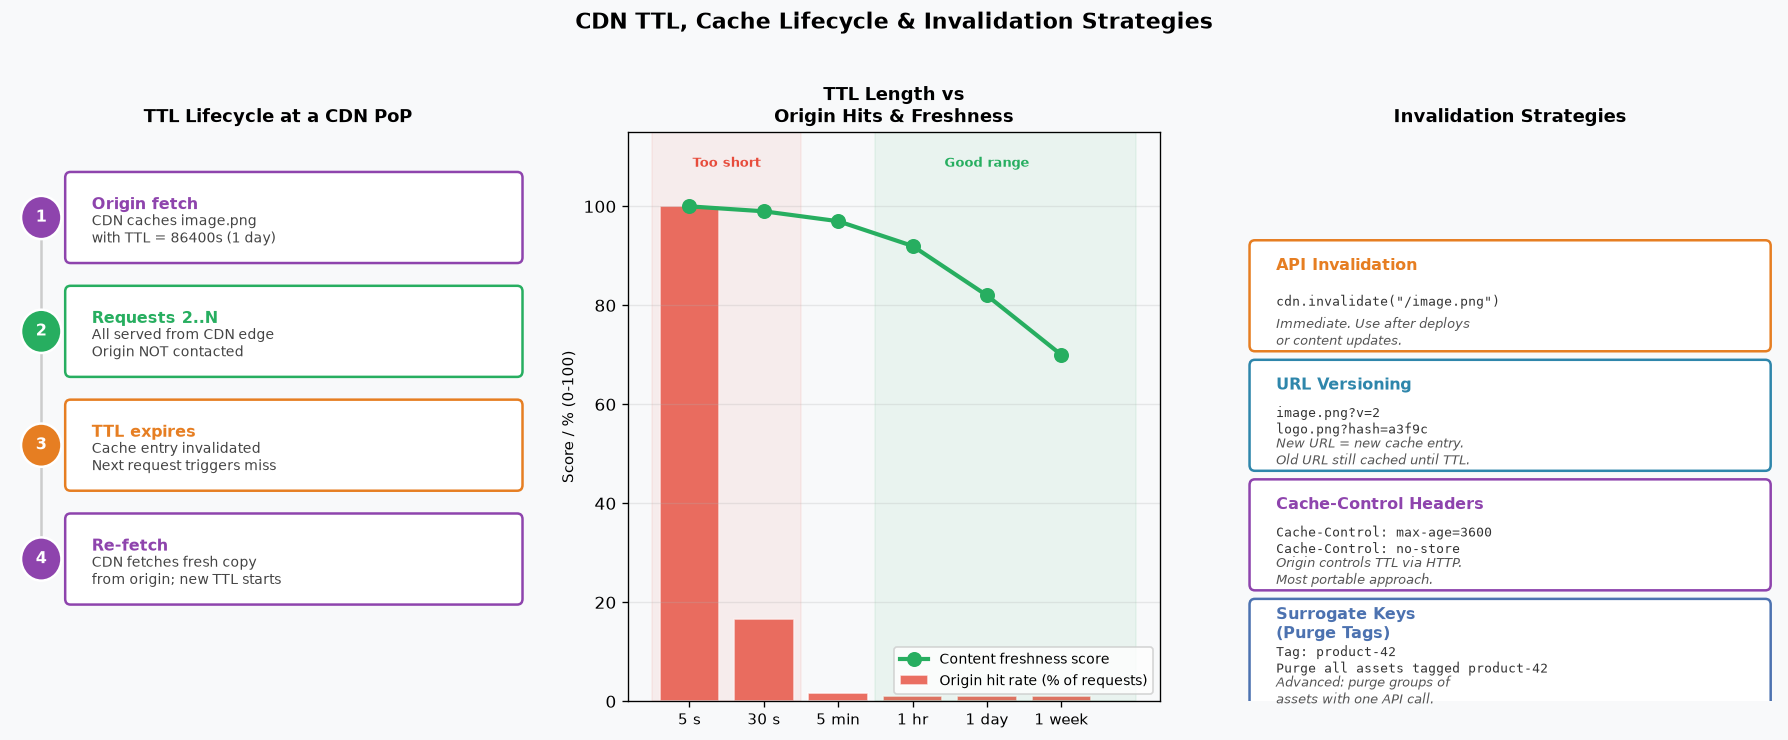

In [5]:
# CDN TTL & cache invalidation strategies

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: TTL lifecycle timeline ──────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('TTL Lifecycle at a CDN PoP', fontsize=11, fontweight='bold')

events = [
    (2.0, 8.5, 'Origin fetch', 'CDN caches image.png\nwith TTL = 86400s (1 day)', C_ORIGIN, 1),
    (2.0, 6.5, 'Requests 2..N', 'All served from CDN edge\nOrigin NOT contacted', C_HIT,   2),
    (2.0, 4.5, 'TTL expires',   'Cache entry invalidated\nNext request triggers miss', C_CDN,  3),
    (2.0, 2.5, 'Re-fetch',      'CDN fetches fresh copy\nfrom origin; new TTL starts', C_ORIGIN, 4),
]
for (x, y, title, body, color, step) in events:
    # Step circle
    circ = plt.Circle((0.55, y), 0.38, facecolor=color, edgecolor='white', lw=1.5)
    ax.add_patch(circ)
    ax.text(0.55, y, str(step), ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    # Box
    r = FancyBboxPatch((1.1, y - 0.7), 8.4, 1.4,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(1.5, y + 0.22, title, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(1.5, y - 0.22, body, ha='left', va='center',
            fontsize=8.5, color='#444')
    # Connector line between steps
    if step < 4:
        ax.plot([0.55, 0.55], [y - 0.4, y - 1.6], color='#CCC', lw=1.5, zorder=0)

# ── Middle: TTL value impact ──────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

ttl_labels = ['5 s', '30 s', '5 min', '1 hr', '1 day', '1 week']
ttl_secs   = [5, 30, 300, 3600, 86400, 604800]
origin_hits = [100 * (1 / t) * 300 for t in ttl_secs]   # conceptual: reqs/5min hitting origin
# Normalise to 0-100
origin_hits = np.clip(np.array(origin_hits) / max(origin_hits) * 100, 1, 100)
freshness   = 100 - np.array([0, 1, 3, 8, 18, 30])  # freshness degrades slowly

x = np.arange(len(ttl_labels))
ax.bar(x, origin_hits,  color=C_MISS,  alpha=0.8, edgecolor='white',
       label='Origin hit rate (% of requests)')
ax.plot(x, freshness, 'o-', color=C_HIT, lw=2.5, ms=8,
        label='Content freshness score', zorder=5)

ax.set_xticks(x); ax.set_xticklabels(ttl_labels, fontsize=9)
ax.set_ylabel('Score / % (0-100)', fontsize=9)
ax.set_title('TTL Length vs\nOrigin Hits & Freshness', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, 115)

ax.axvspan(-0.5, 1.5, alpha=0.07, color=C_MISS, label='Too short: excessive origin hits')
ax.axvspan(2.5, 6.0,  alpha=0.07, color=C_HIT,  label='Good range')
ax.text(0.5, 108, 'Too short', ha='center', fontsize=8, color=C_MISS, fontweight='bold')
ax.text(4.0, 108, 'Good range', ha='center', fontsize=8, color=C_HIT, fontweight='bold')

# ── Right: invalidation methods ──────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Invalidation Strategies', fontsize=11, fontweight='bold')

methods = [
    ('API Invalidation',
     'cdn.invalidate("/image.png")',
     'Immediate. Use after deploys\nor content updates.',
     C_CDN),
    ('URL Versioning',
     'image.png?v=2\nlogo.png?hash=a3f9c',
     'New URL = new cache entry.\nOld URL still cached until TTL.',
     C_TEAL),
    ('Cache-Control Headers',
     'Cache-Control: max-age=3600\nCache-Control: no-store',
     'Origin controls TTL via HTTP.\nMost portable approach.',
     C_ORIGIN),
    ('Surrogate Keys\n(Purge Tags)',
     'Tag: product-42\nPurge all assets tagged product-42',
     'Advanced: purge groups of\nassets with one API call.',
     C_BLUE),
]
y0 = 9.2
for (name, code, note, color) in methods:
    y0 -= 2.1
    r = FancyBboxPatch((0.2, y0 - 0.85), 9.6, 1.75,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(0.6, y0 + 0.55, name, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.6, y0 - 0.08, code, ha='left', va='center',
            fontsize=7.5, color='#333',
            fontfamily='monospace')
    ax.text(0.6, y0 - 0.62, note, ha='left', va='center',
            fontsize=8, color='#555', fontstyle='italic')

plt.suptitle('CDN TTL, Cache Lifecycle & Invalidation Strategies',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_ttl_invalidation.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — TTL Lifecycle (step diagram):**  
Four sequential steps show the complete lifecycle of one cached asset at a PoP. The origin is contacted only at steps 1 and 4 — the TTL period (steps 2-3) is where the CDN delivers its value.

**Middle — TTL Length vs Origin Hits and Freshness:**  
The bar (origin hit rate) falls sharply as TTL increases — longer TTL = less origin load. The green line (freshness) declines gently as TTL grows. The sweet spot is 5 min–1 hour for most assets. Use 1 week for immutable assets (hash-named bundles).

**Right — Invalidation Strategy Cards:**  
Four strategies with code examples. URL versioning is the safest default because it requires no CDN API call — it works by making the new file a different URL entirely, so the old cache entry naturally expires while the new one is immediately available.

## 6. CDN Considerations: Cost, Fallback & Content Classification

**Cost:** CDN transfers are billed per GB. At low traffic, CDN costs more than origin. Above ~100 GB/month, CDN egress ($0.05/GB typical) is cheaper than cloud egress ($0.09/GB from AWS, GCP, Azure) — so CDN actually *reduces* your bill at scale.

**Fallback:** CDN outages are rare but real (Fastly outage June 2021 took down GitHub, Reddit, NYTimes). Your application must detect CDN failure and serve assets directly from origin:
- Set a CDN health-check endpoint
- Use HTTP error handling in JS (`window.onerror` → swap CDN URL for origin URL)
- Configure DNS failover (CNAME pointing to origin as backup)

**Content classification:** CDNs only make sense for static, cacheable content. Dynamic, personalised, or sensitive content must stay at the origin.

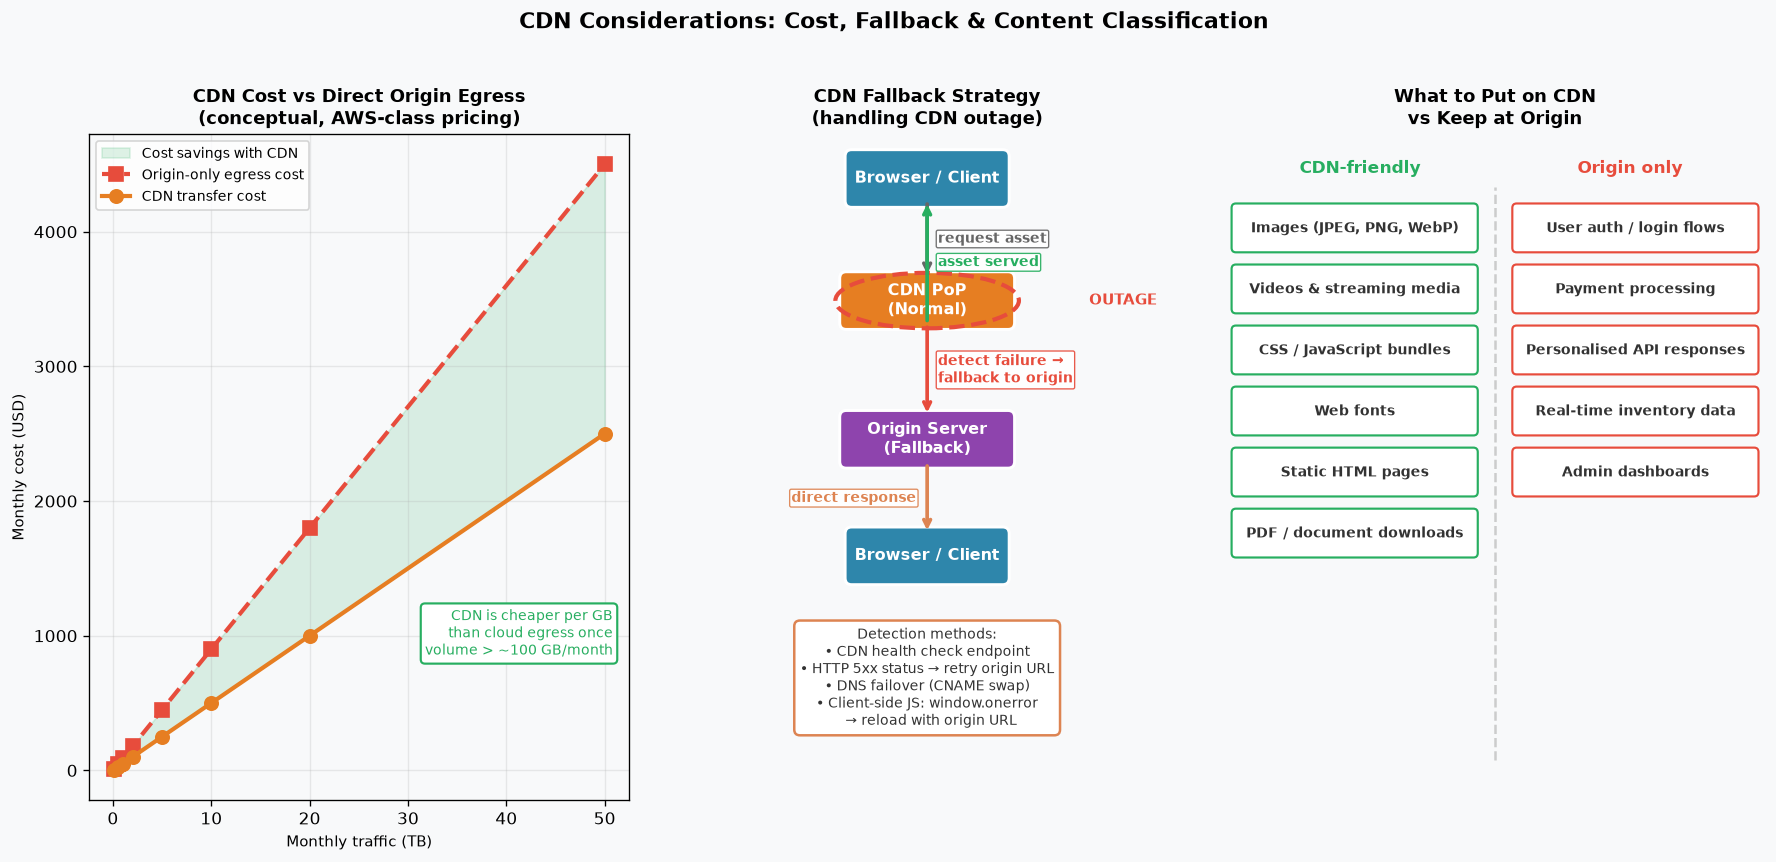

In [6]:
# CDN considerations: cost model, fallback strategy, SPOF

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: CDN cost model ──────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)

traffic_tb = np.array([0.1, 0.5, 1, 2, 5, 10, 20, 50])  # TB / month
# CDN: ~$0.04–0.08/GB; origin egress: ~$0.09/GB (outbound from cloud)
cdn_cost      = traffic_tb * 1000 * 0.05    # $50/TB average
origin_cost   = traffic_tb * 1000 * 0.09    # $90/TB direct from cloud
savings       = origin_cost - cdn_cost

ax.fill_between(traffic_tb, cdn_cost, origin_cost, alpha=0.15, color=C_HIT,
                label='Cost savings with CDN')
ax.plot(traffic_tb, origin_cost, 's--', color=C_MISS,  lw=2.5, ms=8,
        label='Origin-only egress cost')
ax.plot(traffic_tb, cdn_cost,    'o-',  color=C_CDN,   lw=2.5, ms=8,
        label='CDN transfer cost')

ax.set_xlabel('Monthly traffic (TB)', fontsize=9)
ax.set_ylabel('Monthly cost (USD)', fontsize=9)
ax.set_title('CDN Cost vs Direct Origin Egress\n(conceptual, AWS-class pricing)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)
ax.text(0.97, 0.25,
        'CDN is cheaper per GB\nthan cloud egress once\nvolume > ~100 GB/month',
        ha='right', va='center', transform=ax.transAxes, fontsize=8.5,
        color=C_HIT,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_HIT, lw=1.3))

# ── Middle: fallback strategy diagram ────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('CDN Fallback Strategy\n(handling CDN outage)', fontsize=11, fontweight='bold')

def node(ax, x, y, w, h, label, color, sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.25, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

def arr(ax, x1, y1, x2, y2, label, color, side='right'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    mx, my = (x1+x2)/2, (y1+y2)/2
    dx = 0.2 if side == 'right' else -0.2
    ax.text(mx + dx, my, label, ha='left' if side == 'right' else 'right',
            va='center', fontsize=8.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                      edgecolor=color, lw=0.8, alpha=0.92))

node(ax, 5, 11.2, 2.8, 0.8, 'Browser / Client', C_USER)

# Normal path
node(ax, 5, 9.0,  3.0, 0.8, 'CDN PoP\n(Normal)', C_CDN)
arr(ax, 5, 10.8, 5, 9.42, 'request asset', '#666')
arr(ax, 5, 8.58, 5, 10.8, 'asset served', C_HIT)

# Failure + fallback
ax.add_patch(plt.matplotlib.patches.Ellipse((5, 9.0), 3.4, 1.0,
             fill=False, edgecolor=C_MISS, lw=2.5, linestyle='--'))
ax.text(8.0, 9.0, 'OUTAGE', ha='left', va='center',
        fontsize=9, color=C_MISS, fontweight='bold')

node(ax, 5, 6.5, 3.0, 0.8, 'Origin Server\n(Fallback)', C_ORIGIN)
arr(ax, 5, 8.58, 5, 6.92, 'detect failure →\nfallback to origin', C_MISS)
arr(ax, 5, 6.08, 5, 4.8, 'direct response', C_ORANGE, side='left')
node(ax, 5, 4.4, 2.8, 0.8, 'Browser / Client', C_USER)

detect_txt = (
    'Detection methods:\n'
    '• CDN health check endpoint\n'
    '• HTTP 5xx status → retry origin URL\n'
    '• DNS failover (CNAME swap)\n'
    '• Client-side JS: window.onerror\n'
    '  → reload with origin URL'
)
ax.text(5, 2.2, detect_txt, ha='center', va='center', fontsize=8.5,
        color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.5))

# ── Right: what to put on CDN vs not ─────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('What to Put on CDN\nvs Keep at Origin', fontsize=11, fontweight='bold')

cdn_items = [
    ('Images (JPEG, PNG, WebP)', C_HIT),
    ('Videos & streaming media', C_HIT),
    ('CSS / JavaScript bundles', C_HIT),
    ('Web fonts', C_HIT),
    ('Static HTML pages', C_HIT),
    ('PDF / document downloads', C_HIT),
]
origin_items = [
    ('User auth / login flows', C_MISS),
    ('Payment processing', C_MISS),
    ('Personalised API responses', C_MISS),
    ('Real-time inventory data', C_MISS),
    ('Admin dashboards', C_MISS),
]

ax.text(2.5, 11.3, 'CDN-friendly', ha='center', fontsize=10,
        fontweight='bold', color=C_HIT)
ax.text(7.5, 11.3, 'Origin only', ha='center', fontsize=10,
        fontweight='bold', color=C_MISS)
ax.axvline(5.0, ymin=0.06, ymax=0.92, color='#CCC', lw=1.5, linestyle='--')

for i, (item, color) in enumerate(cdn_items):
    y = 10.3 - i * 1.1
    r = FancyBboxPatch((0.2, y - 0.35), 4.4, 0.72,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.3)
    ax.add_patch(r)
    ax.text(2.4, y, item, ha='center', va='center',
            fontsize=8.5, color='#333', fontweight='bold')

for i, (item, color) in enumerate(origin_items):
    y = 10.3 - i * 1.1
    r = FancyBboxPatch((5.4, y - 0.35), 4.4, 0.72,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.3)
    ax.add_patch(r)
    ax.text(7.6, y, item, ha='center', va='center',
            fontsize=8.5, color='#333', fontweight='bold')

plt.suptitle('CDN Considerations: Cost, Fallback & Content Classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_considerations.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Cost Model:**  
The green shaded area is the cost savings from using a CDN instead of direct cloud egress. The crossover happens quickly (within the first few hundred GB/month). At 10 TB/month, CDN saves hundreds of dollars compared to paying cloud provider egress rates.

**Middle — Fallback Strategy Flow:**  
The normal path (User → CDN PoP) is shown with a SPOF-style dashed circle. On outage, the client detects failure and the request is redirected to the origin server directly. Detection methods are listed: health check endpoint, HTTP 5xx retry, DNS failover, client-side JS.

**Right — Content Classification:**  
Green (CDN-friendly): images, video, CSS/JS, fonts, static HTML, PDFs — all cacheable and safe to serve stale.  
Red (origin only): auth flows, payments, personalised API responses, real-time inventory, admin dashboards — these must always be served fresh from the origin.

## 7. Pull CDN vs Push CDN + Provider Landscape

**Pull CDN** (most common):
- The CDN fetches content from your origin on the first request (lazy population)
- Simple to set up — just point DNS CNAME at the CDN
- Works well for high-traffic sites where popular content is naturally cached

**Push CDN:**
- You upload files to the CDN at deploy time — all PoPs are pre-populated
- Better for large files (video, game assets) where you know exactly what users will need
- Higher control, more operational overhead

**Choosing a provider:** Cloudflare is the default choice for most web apps (free tier, DDoS protection). AWS CloudFront for AWS-native stacks. Fastly for real-time purging. Akamai for enterprise/media.

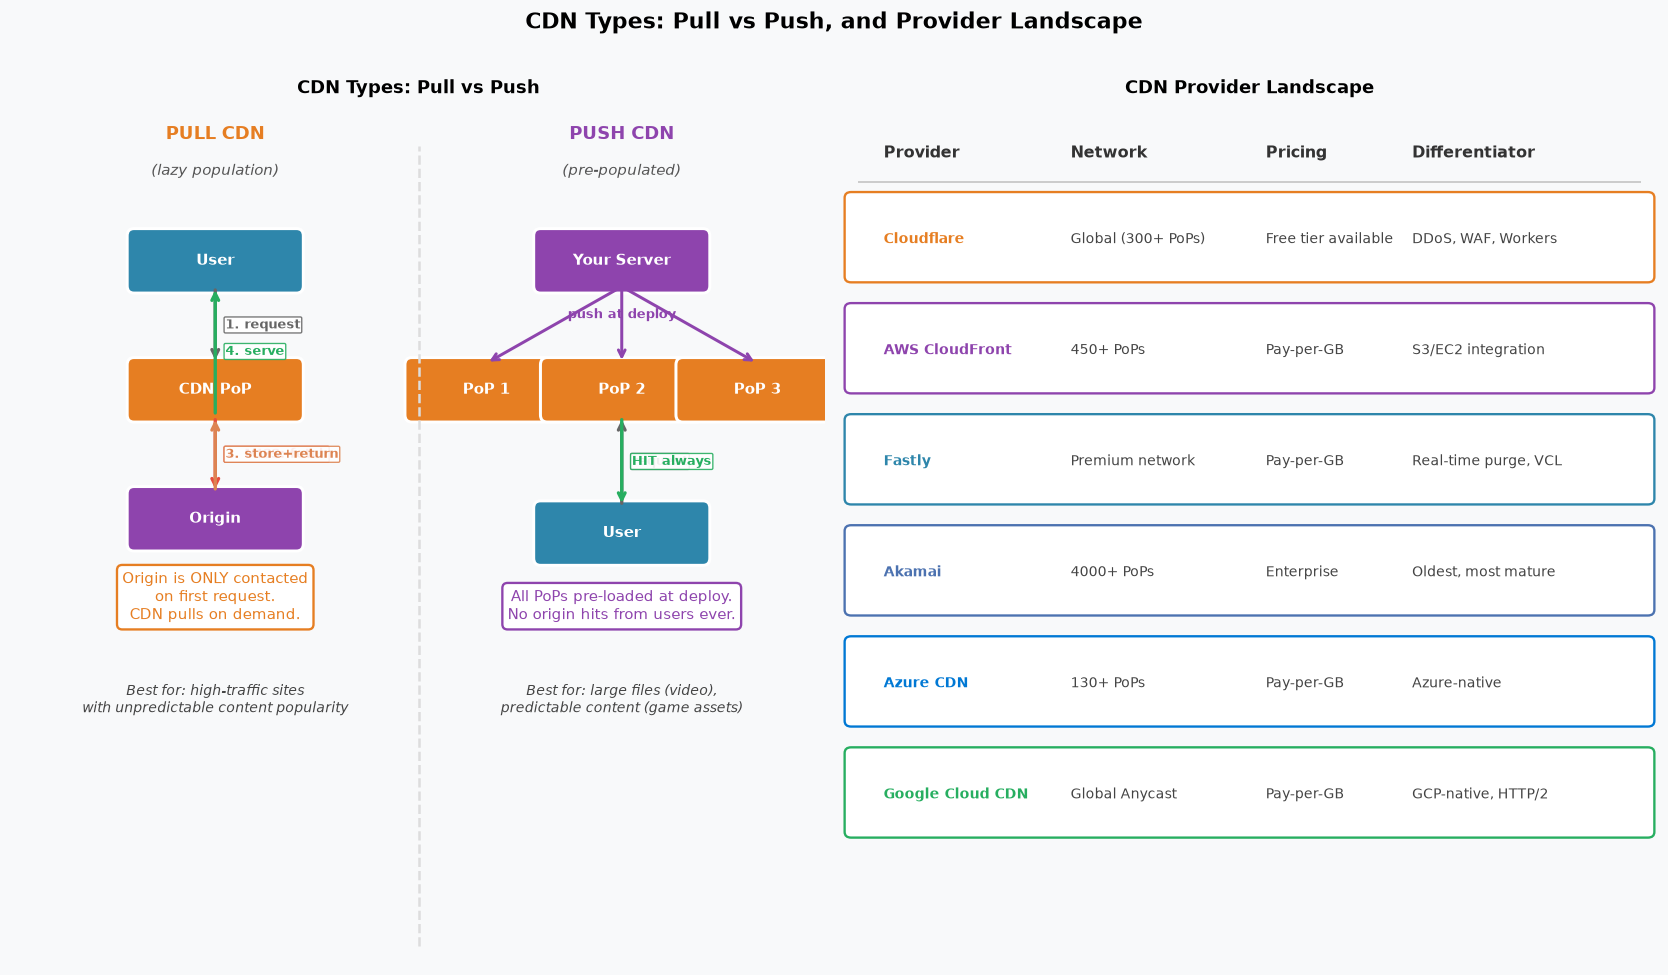

In [7]:
# CDN types comparison: Pull vs Push + provider landscape

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

# ── Left: Pull CDN vs Push CDN side-by-side flow ─────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('CDN Types: Pull vs Push', fontsize=11, fontweight='bold')

def sbox(ax, x, y, w, h, label, color, sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.1',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label,
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.23, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

def sarr(ax, x1, y1, x2, y2, label, color):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2
    ax.text(mx, my, label, ha='left', va='center',
            fontsize=8, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                      edgecolor=color, lw=0.8, alpha=0.9))

# Pull CDN (left column)
ax.text(3, 11.5, 'PULL CDN', ha='center', fontsize=11,
        fontweight='bold', color=C_CDN)
ax.text(3, 11.0, '(lazy population)', ha='center', fontsize=9,
        color='#555', fontstyle='italic')
sbox(ax, 3, 9.8, 2.4, 0.7, 'User', C_USER)
sbox(ax, 3, 8.0, 2.4, 0.7, 'CDN PoP', C_CDN)
sbox(ax, 3, 6.2, 2.4, 0.7, 'Origin', C_ORIGIN)

sarr(ax, 3, 9.44, 3, 8.37, '1. request', '#666')
sarr(ax, 3, 7.63, 3, 6.57, '2. MISS: fetch', C_MISS)
sarr(ax, 3, 6.57, 3, 7.63, '3. store+return', C_ORANGE)
sarr(ax, 3, 7.63, 3, 9.44, '4. serve', C_HIT)

ax.text(3, 4.8,
        'Origin is ONLY contacted\non first request.\nCDN pulls on demand.',
        ha='center', fontsize=9, color=C_CDN,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_CDN, lw=1.4))
ax.text(3, 3.5, 'Best for: high-traffic sites\nwith unpredictable content popularity',
        ha='center', fontsize=8.5, color='#444', fontstyle='italic')

# Push CDN (right column)
ax.text(9, 11.5, 'PUSH CDN', ha='center', fontsize=11,
        fontweight='bold', color=C_ORIGIN)
ax.text(9, 11.0, '(pre-populated)', ha='center', fontsize=9,
        color='#555', fontstyle='italic')
sbox(ax, 9, 9.8, 2.4, 0.7, 'Your Server', C_ORIGIN)
sbox(ax, 7, 8.0, 2.2, 0.7, 'PoP 1', C_CDN)
sbox(ax, 9, 8.0, 2.2, 0.7, 'PoP 2', C_CDN)
sbox(ax, 11,8.0, 2.2, 0.7, 'PoP 3', C_CDN)
sbox(ax, 9, 6.0, 2.4, 0.7, 'User', C_USER)

# Push: server pushes to all PoPs at deploy time
for px in [7, 9, 11]:
    ax.annotate('', xy=(px, 8.37), xytext=(9, 9.44),
                arrowprops=dict(arrowstyle='->', color=C_ORIGIN, lw=1.8))
ax.text(9, 9.0, 'push at deploy', ha='center', fontsize=7.5,
        color=C_ORIGIN, fontweight='bold')

# User request hits nearest PoP directly
sarr(ax, 9, 6.37, 9, 7.63, 'request', '#666')
sarr(ax, 9, 7.63, 9, 6.37, 'HIT always', C_HIT)

ax.text(9, 4.8,
        'All PoPs pre-loaded at deploy.\nNo origin hits from users ever.',
        ha='center', fontsize=9, color=C_ORIGIN,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_ORIGIN, lw=1.4))
ax.text(9, 3.5, 'Best for: large files (video),\npredictable content (game assets)',
        ha='center', fontsize=8.5, color='#444', fontstyle='italic')

# Divider
ax.axvline(6, ymin=0.02, ymax=0.95, color='#DDD', lw=1.5, linestyle='--')

# ── Right: CDN provider comparison table ─────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('CDN Provider Landscape', fontsize=11, fontweight='bold')

providers = [
    ('Cloudflare',      'Global (300+ PoPs)', 'Free tier available', 'DDoS, WAF, Workers',  C_CDN),
    ('AWS CloudFront',  '450+ PoPs',           'Pay-per-GB',          'S3/EC2 integration',   C_ORIGIN),
    ('Fastly',          'Premium network',     'Pay-per-GB',          'Real-time purge, VCL', C_TEAL),
    ('Akamai',          '4000+ PoPs',          'Enterprise',          'Oldest, most mature',  C_BLUE),
    ('Azure CDN',       '130+ PoPs',           'Pay-per-GB',          'Azure-native',         '#0078D4'),
    ('Google Cloud CDN','Global Anycast',      'Pay-per-GB',          'GCP-native, HTTP/2',   C_GREEN),
]

headers = ['Provider', 'Network', 'Pricing', 'Differentiator']
col_x = [0.5, 2.8, 5.2, 7.0]
ax.text(5, 11.5, '', ha='center')

# Header
for cx, hdr in zip(col_x, headers):
    ax.text(cx, 11.3, hdr, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color='#333')
ax.axhline(10.9, xmin=0.02, xmax=0.98, color='#CCC', lw=1.2)

for i, (name, network, pricing, diff, color) in enumerate(providers):
    y = 10.1 - i * 1.55
    r = FancyBboxPatch((0.1, y - 0.52), 9.8, 1.1,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    for cx, val in zip(col_x, [name, network, pricing, diff]):
        fw = 'bold' if val == name else 'normal'
        fc = color if val == name else '#444'
        ax.text(cx, y, val, ha='left', va='center',
                fontsize=8.5, fontweight=fw, color=fc)

plt.suptitle('CDN Types: Pull vs Push, and Provider Landscape',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_types.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Pull vs Push flow comparison:**  
Two independent vertical flows side by side (no crossing arrows). Pull (left column): the CDN contacts the origin only on a miss. Push (right column): the server pushes content to all PoPs at deploy time — from that point every user request is always a HIT.

**Right — Provider table:**  
Six major CDN providers with their network size, pricing model, and key differentiator. Note the scale difference: Akamai (4000+ PoPs, founded 1998) vs Azure CDN (130+ PoPs). For most startups, Cloudflare's free tier or AWS CloudFront is the right starting point.

## 8. Architecture Evolution & Scorecard

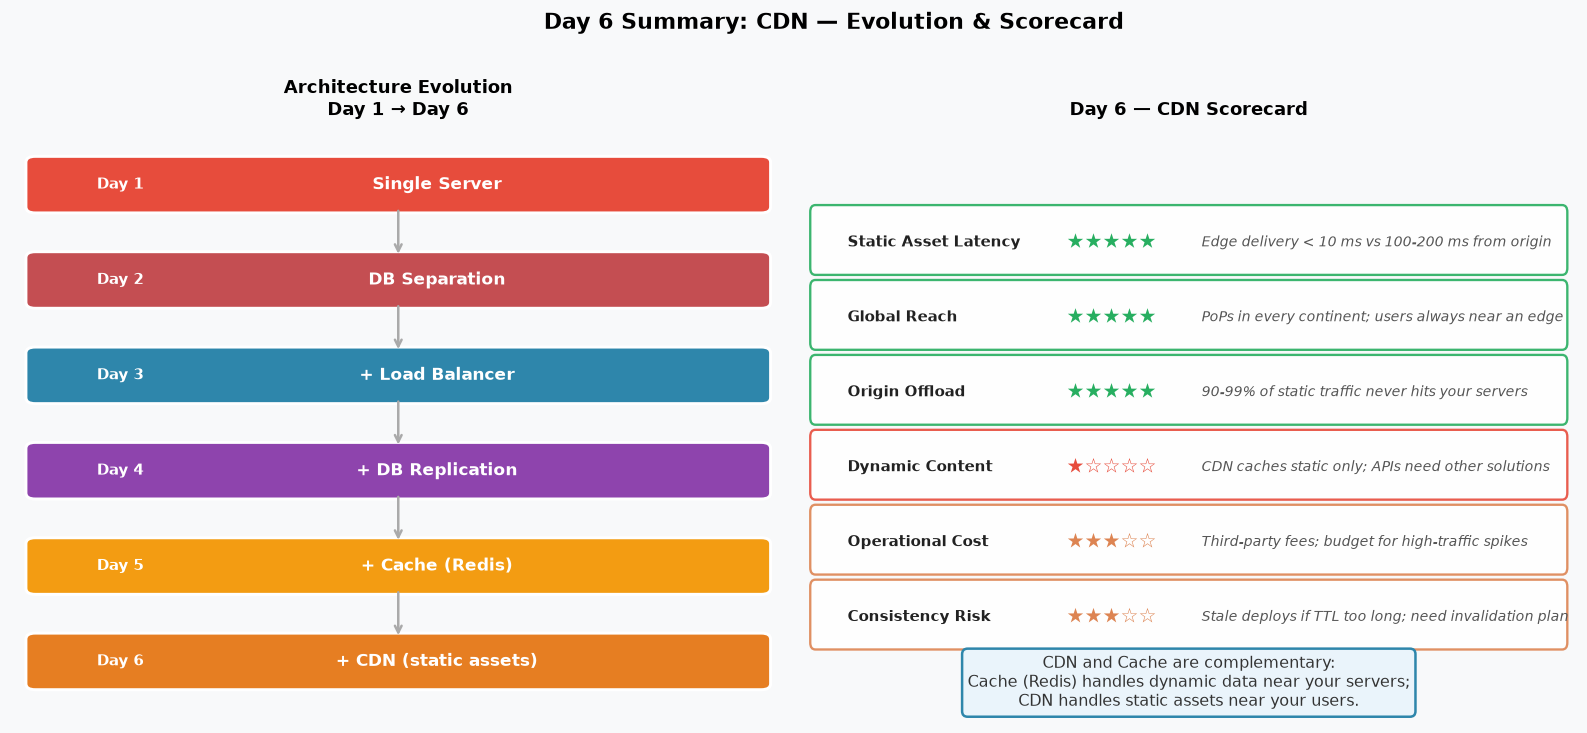

Day 6 complete.


In [8]:
# Day 6 Scorecard + Evolution Day 1 -> 6

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 6', fontsize=11, fontweight='bold')

days = [
    ('Day 1', 'Single Server',             C_MISS),
    ('Day 2', 'DB Separation',             C_RED),
    ('Day 3', '+ Load Balancer',           C_TEAL),
    ('Day 4', '+ DB Replication',          C_ORIGIN),
    ('Day 5', '+ Cache (Redis)',           '#F39C12'),
    ('Day 6', '+ CDN (static assets)',     C_CDN),
]
ys = np.linspace(10.8, 1.2, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.45), 9.4, 0.9,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.46), xytext=(5, y - 0.46),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 6 — CDN Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Static Asset Latency', '★★★★★', C_HIT,
     'Edge delivery < 10 ms vs 100-200 ms from origin'),
    ('Global Reach',         '★★★★★', C_HIT,
     'PoPs in every continent; users always near an edge'),
    ('Origin Offload',       '★★★★★', C_HIT,
     '90-99% of static traffic never hits your servers'),
    ('Dynamic Content',      '★☆☆☆☆', C_MISS,
     'CDN caches static only; APIs need other solutions'),
    ('Operational Cost',     '★★★☆☆', '#DD8452',
     'Third-party fees; budget for high-traffic spikes'),
    ('Consistency Risk',     '★★★☆☆', '#DD8452',
     'Stale deploys if TTL too long; need invalidation plan'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4, alpha=0.9)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.8,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.2,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'CDN and Cache are complementary:\n'
        'Cache (Redis) handles dynamic data near your servers;\n'
        'CDN handles static assets near your users.',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.suptitle('Day 6 Summary: CDN — Evolution & Scorecard',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day6_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 6 complete.")


### What this shows

**Left — Evolution Day 1 → Day 6:**  
Day 6 adds the CDN layer above the load balancer. Static assets (images, CSS, JS) never reach the web servers at all — they are served from the CDN edge. This offloads the majority of HTTP traffic, leaving web servers free for dynamic requests only.

**Right — Day 6 CDN Scorecard:**  
- **Static Asset Latency (5/5):** Sub-10 ms from any region vs 100-200 ms without CDN.
- **Global Reach (5/5):** PoPs on every continent mean consistent performance worldwide.
- **Origin Offload (5/5):** 90-99% of static traffic never hits your infrastructure.
- **Dynamic Content (1/5):** CDN is useless for personalised or real-time data — that is still the application server's job.
- **Operational Cost (3/5):** CDN fees add up; budget carefully for viral traffic spikes.
- **Consistency Risk (3/5):** Long TTLs cause stale deploys — always pair CDN with an invalidation strategy.

**Key insight:** Cache (Day 5) and CDN (Day 6) are complementary layers. Redis handles dynamic data at the server tier; CDN handles static assets at the network edge. Together they form a two-level caching hierarchy that covers almost every read bottleneck.